In [ ]:
from huggingface_hub import login
login()

In [ ]:
import os
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import string
import re
import numpy as np
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print(f"TensorFlow Version: {tf.__version__}")
gpu = len(tf.config.list_physical_devices('GPU')) > 0
print("GPU is", "AVAILABLE" if gpu else "NOT AVAILABLE")

TensorFlow Version: 2.19.0
GPU is AVAILABLE


In [ ]:
# PART 1:  PREPROCESSING


class DataPreprocessor:
    def __init__(self):
        self.preprocessing_log = []
        self.stats = {}

    def log_step(self, step_name, details):
        self.preprocessing_log.append({
            'step': step_name,
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'details': details
        })
        print(f"  \u2713 {step_name}")

    def clean_text(self, text, text_type="source"):
        text = str(text)
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\S+@\S+', '', text)

        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        contractions = {
            r"won't": "will not", r"can't": "cannot", r"n't": " not",
            r"'re": " are", r"'s": " is", r"'d": " would",
            r"'ll": " will", r"'t": " not", r"'ve": " have", r"'m": " am"
        }
        for pattern, replacement in contractions.items():
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def normalize_text(self, text):
        import unicodedata
        text = text.lower()
        text = re.sub(r'\d+', '<NUM>', text)
        text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('ASCII')
        text = re.sub(r'[""]', '"', text)
        text = re.sub(r"['\u2019]", "'", text)
        text = re.sub(r'[^\w\s<>"\']', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def analyze_dataset(self, df, source_col, target_col):

        print("DATASET ANALYSIS")


        analysis = {
            'total_samples': len(df),
            'source_stats': {
                'avg_length': df[source_col].str.len().mean(),
                'max_length': df[source_col].str.len().max(),
                'min_length': df[source_col].str.len().min(),
                'unique_words': len(set(' '.join(df[source_col]).split())),
            },
            'target_stats': {
                'avg_length': df[target_col].str.len().mean(),
                'max_length': df[target_col].str.len().max(),
                'min_length': df[target_col].str.len().min(),
                'unique_words': len(set(' '.join(df[target_col]).split())),
            },
            'missing_values': {
                'source': df[source_col].isnull().sum(),
                'target': df[target_col].isnull().sum()
            },
            'duplicates': df.duplicated().sum()
        }

        print(f"  Total samples: {analysis['total_samples']}")
        print(f"  Duplicates: {analysis['duplicates']}")
        print(f"  Source avg length: {analysis['source_stats']['avg_length']:.1f} chars")
        print(f"  Target avg length: {analysis['target_stats']['avg_length']:.1f} chars")
        return analysis

    def prepare_data(self, df, source_col, target_col):
        print("PREPROCESSING PIPELINE")


        initial_analysis = self.analyze_dataset(df, source_col, target_col)
        self.stats['initial'] = initial_analysis

        print("\n Step 1: Handling missing values...")
        missing_source = df[source_col].isnull().sum()
        missing_target = df[target_col].isnull().sum()
        df = df.dropna(subset=[source_col, target_col])
        self.log_step('missing_value_handling', {
            'missing_source_removed': int(missing_source),
            'missing_target_removed': int(missing_target)
        })

        print("\n Step 2: Removing duplicates...")
        duplicate_count = df.duplicated().sum()
        df = df.drop_duplicates()
        self.log_step('duplicate_removal', {'duplicates_removed': int(duplicate_count)})

        print("\n Step 3: Cleaning texts...")
        df = df.copy()
        df['source_cleaned'] = df[source_col].apply(lambda x: self.clean_text(x, "source"))
        df['target_cleaned'] = df[target_col].apply(lambda x: self.clean_text(x, "target"))
        self.log_step('text_cleaning', {'samples': len(df)})

        print("\n Step 4: Normalizing texts...")
        df['source_normalized'] = df['source_cleaned'].apply(self.normalize_text)
        df['target_normalized'] = df['target_cleaned'].apply(self.normalize_text)
        self.log_step('text_normalization', {})

        print("\n Step 5: Filtering empty strings...")
        empty_source = (df['source_normalized'] == '').sum()
        empty_target = (df['target_normalized'] == '').sum()
        df = df[df['source_normalized'] != '']
        df = df[df['target_normalized'] != '']
        self.log_step('empty_filter', {
            'empty_source_removed': int(empty_source),
            'empty_target_removed': int(empty_target)
        })

        print("\n Step 6: Length-based filtering...")
        df = df[df['source_normalized'].str.len() <= 500]
        df = df[df['target_normalized'].str.len() <= 500]
        self.log_step('length_filtering', {'max_length_allowed': 500})

        final_analysis = self.analyze_dataset(df, 'source_normalized', 'target_normalized')
        self.stats['final'] = final_analysis

        documentation = {
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'initial_stats': initial_analysis,
            'final_stats': final_analysis,
            'preprocessing_steps': self.preprocessing_log,
            'data_reduction': {
                'initial_samples': initial_analysis['total_samples'],
                'final_samples': final_analysis['total_samples'],
                'reduction_percentage': (1 - final_analysis['total_samples'] / initial_analysis['total_samples']) * 100
            }
        }

        def default_json_encoder(obj):
            if isinstance(obj, np.integer): return int(obj)
            elif isinstance(obj, np.floating): return float(obj)
            raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

        with open('preprocessing_documentation.json', 'w') as f:
            json.dump(documentation, f, indent=2, default=default_json_encoder)

        print(f"\n  Initial: {initial_analysis['total_samples']} -> Final: {final_analysis['total_samples']} samples")
        print(f"  Documentation saved to 'preprocessing_documentation.json'")
        return df


print("# PART 1: DATA PREPROCESSING")

df = pd.read_csv('/content/data.csv', usecols=[1, 2])
df.columns = ['source', 'target']
df = df.astype(str)

preprocessor = DataPreprocessor()
df = preprocessor.prepare_data(df, 'source', 'target')
df['source'] = df['source_normalized']
df['target'] = df['target_normalized']

print("\nRandom samples after preprocessing:")
print(df[['source', 'target']].sample(5))



# PART 1: DATA PREPROCESSING
PREPROCESSING PIPELINE
DATASET ANALYSIS
  Total samples: 18587
  Duplicates: 2626
  Source avg length: 95.3 chars
  Target avg length: 264.1 chars

 Step 1: Handling missing values...
  ✓ missing_value_handling

 Step 2: Removing duplicates...
  ✓ duplicate_removal

 Step 3: Cleaning texts...
  ✓ text_cleaning

 Step 4: Normalizing texts...
  ✓ text_normalization

 Step 5: Filtering empty strings...
  ✓ empty_filter

 Step 6: Length-based filtering...
  ✓ length_filtering
DATASET ANALYSIS
  Total samples: 15073
  Duplicates: 0
  Source avg length: 92.5 chars
  Target avg length: 236.7 chars

  Initial: 18587 -> Final: 15073 samples
  Documentation saved to 'preprocessing_documentation.json'

Random samples after preprocessing:
                                                  source  \
7768   how can family members and caregivers support ...   
6179   can nicotine interventions be considered in in...   
3824   should individuals with a history of blood can.

In [ ]:
# PART 2: EXPERIMENT TRACKING

class ExperimentTracker:
    def __init__(self):
        self.experiments = []
        self.best_score = 0
        self.best_config = None
        self.baseline_performance = None

    def set_baseline(self, metrics):
        self.baseline_performance = metrics
        print(f"\n  Baseline - Accuracy: {metrics.get('accuracy', 0):.4f}  Loss: {metrics.get('loss', 0):.4f}")

    def add_experiment(self, config, metrics, notes=""):
        improvement = 0
        if self.baseline_performance:
            baseline_acc = self.baseline_performance.get('accuracy', 0)
            current_acc = metrics.get('val_accuracy', 0)
            if baseline_acc > 0:
                improvement = ((current_acc - baseline_acc) / baseline_acc) * 100

        experiment = {
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'config': config,
            'metrics': metrics,
            'improvement_over_baseline': f"{improvement:.2f}%",
            'notes': notes
        }
        self.experiments.append(experiment)

        if metrics.get('val_accuracy', 0) > self.best_score:
            self.best_score = metrics['val_accuracy']
            self.best_config = config
            print(f"  New best model! Val Accuracy: {self.best_score:.4f}")

        self.save_experiments()

    def save_experiments(self):
        with open('hyperparameter_experiments.json', 'w') as f:
            json.dump(self.experiments, f, indent=2)

    def display_comparison_table(self):
        print("\n" + "="*100)
        print("HYPERPARAMETER EXPERIMENT COMPARISON")
        print("="*100)

        comparison_data = []
        for exp in self.experiments:
            comparison_data.append({
                'Experiment': len(comparison_data) + 1,
                'Name': exp['config'].get('name', 'N/A'),
                'Embed': exp['config'].get('embed_dim', 'N/A'),
                'Dense': exp['config'].get('dense_dim', 'N/A'),
                'Heads': exp['config'].get('num_heads', 'N/A'),
                'Batch': exp['config'].get('batch_size', 'N/A'),
                'LR': exp['config'].get('learning_rate', 'N/A'),
                'Dropout': exp['config'].get('dropout', 'N/A'),
                'Val Acc': f"{exp['metrics'].get('val_accuracy', 0):.4f}",
                'Val Loss': f"{exp['metrics'].get('val_loss', 0):.4f}",
                'Improvement': exp['improvement_over_baseline'],
                'Status': exp['metrics'].get('status', 'OK')
            })

        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))

        valid = [e for e in self.experiments if e['metrics'].get('status', 'OK') == 'OK']
        if valid:
            best_idx = np.argmax([e['metrics'].get('val_accuracy', 0) for e in valid])
            print(f"\n  Best: {valid[best_idx]['config']['name']}  "
                  f"Val Acc: {valid[best_idx]['metrics']['val_accuracy']:.4f}")
        return comparison_df


tracker = ExperimentTracker()



Split sizes -> Train: 13565  Val: 753  Test: 755


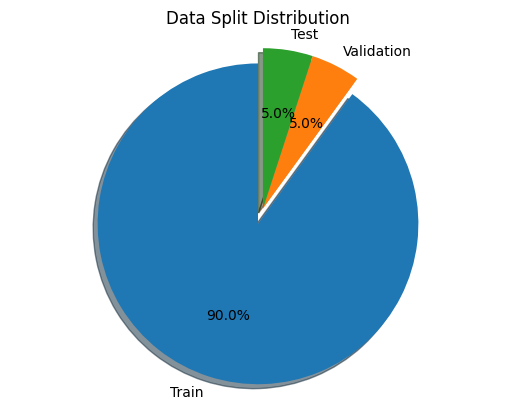

In [ ]:
# VECTORIZATION

max_tokens = 25000
sequence_length = 200

strip_chars = string.punctuation.replace("[", "").replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, "[" + re.escape(strip_chars) + "]", "")

source_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
)

target_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

# Shuffle and split
df = df.sample(frac=1).reset_index(drop=True)
train_size = int(len(df) * 0.90)
val_size   = int(len(df) * 0.05)

train_df = df[:train_size]
val_df   = df[train_size:train_size + val_size]
test_df  = df[train_size + val_size:]

print(f"\nSplit sizes -> Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# Pie chart
labels = ['Train', 'Validation', 'Test']
sizes  = [len(train_df), len(val_df), len(test_df)]
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=(0.1, 0, 0), labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')
plt.title('Data Split Distribution')
plt.show()

# Prepare text arrays
train_source_texts = train_df['source'].values
train_target_texts = ["[start] " + t + " [end]" for t in train_df['target'].values]

val_source_texts = val_df['source'].values
val_target_texts = ["[start] " + t + " [end]" for t in val_df['target'].values]

test_source_texts = test_df['source'].values
test_target_texts = ["[start] " + t + " [end]" for t in test_df['target'].values]

# Adapt on training data only
source_vectorization.adapt(train_source_texts)
target_vectorization.adapt(train_target_texts)

In [ ]:
def make_dataset(source_texts, target_texts, batch_size):
    """
    Build a tf.data pipeline.
    FIX: cache() BEFORE shuffle() so the dataset is cached in its original
    order and then shuffled each epoch — avoids freezing the shuffle.
    """
    src = source_vectorization(source_texts)
    tgt = target_vectorization(target_texts)

    enc_input = src
    dec_input = tgt[:, :-1]
    dec_target = tgt[:, 1:]

    dataset = tf.data.Dataset.from_tensor_slices((
        {"source": enc_input, "target": dec_input},
        dec_target
    ))
    return (
        dataset
        .cache()                               # cache before shuffle
        .shuffle(buffer_size=len(source_texts))
        .batch(batch_size, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )


In [ ]:
# TRANSFORMER COMPONENTS
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = tf.keras.layers.Embedding(
            input_dim=input_dim, output_dim=output_dim, mask_zero=True)
        self.position_embeddings = tf.keras.layers.Embedding(
            input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        return self.token_embeddings(inputs) + self.position_embeddings(positions)

    def compute_mask(self, inputs, mask=None):
        return self.token_embeddings.compute_mask(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({"input_dim": self.input_dim, "output_dim": self.output_dim,
                        "sequence_length": self.sequence_length})
        return config



In [ ]:
def shape_list(x):
    static = x.shape.as_list()
    dynamic = tf.shape(x)
    return [dynamic[i] if s is None else s for i, s in enumerate(static)]


def attention_mask(nd, ns, *, dtype):
    i = tf.range(nd)[:, None]
    j = tf.range(ns)
    return tf.cast(i >= j - ns + nd, dtype)


def mask_attn_weights(w):
    _, _, nd, ns = shape_list(w)
    b = tf.reshape(attention_mask(nd, ns, dtype=w.dtype), [1, 1, nd, ns])
    return w * b - tf.cast(1e10, w.dtype) * (1 - b)


def scaled_dot_product_attention(q, k, v, use_causal_mask=False, key_padding_mask=None):
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(d_k)
    if use_causal_mask:
        scaled_scores = mask_attn_weights(scaled_scores)
    if key_padding_mask is not None:
        key_padding_mask = tf.cast(key_padding_mask[:, tf.newaxis, tf.newaxis, :], scaled_scores.dtype)
        scaled_scores += (key_padding_mask - 1) * 1e9
    return tf.matmul(tf.nn.softmax(scaled_scores, axis=-1), v)

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim, h, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.h = h
        if embed_dim % h != 0:
            raise ValueError(f"embed_dim ({embed_dim}) must be divisible by num_heads ({h})")
        self.q_linear = tf.keras.layers.Dense(embed_dim)
        self.k_linear = tf.keras.layers.Dense(embed_dim)
        self.v_linear = tf.keras.layers.Dense(embed_dim)
        self.concat_linear = tf.keras.layers.Dense(embed_dim)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.h, self.embed_dim // self.h))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def concat_heads(self, x, batch_size):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        return tf.reshape(x, (batch_size, -1, self.embed_dim))

    def call(self, q, k, v, use_causal_mask=False, key_padding_mask=None):
        batch_size = tf.shape(k)[0]
        q = self.split_heads(self.q_linear(q), batch_size)
        k = self.split_heads(self.k_linear(k), batch_size)
        v = self.split_heads(self.v_linear(v), batch_size)
        attention = scaled_dot_product_attention(q, k, v, use_causal_mask, key_padding_mask)
        return self.concat_linear(self.concat_heads(attention, batch_size))

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "h": self.h})
        return config

In [ ]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.global_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.feed_forward = tf.keras.Sequential([
            tf.keras.layers.Dense(dense_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.supports_masking = True

    def call(self, x, mask=None):
        x = self.layer_norm_1(x + self.global_self_attention(q=x, k=x, v=x, key_padding_mask=mask))
        x = self.layer_norm_2(x + self.feed_forward(x))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "dense_dim": self.dense_dim, "num_heads": self.num_heads})
        return config

In [ ]:
class TransformerDecoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.causal_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.cross_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.feed_forward = tf.keras.Sequential([
            tf.keras.layers.Dense(dense_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.layer_norm_3 = tf.keras.layers.LayerNormalization()
        self.supports_masking = True

    def call(self, x, context, mask=None, context_mask=None):
        x = self.layer_norm_1(
            x + self.causal_self_attention(q=x, k=x, v=x, use_causal_mask=True, key_padding_mask=mask))
        x = self.layer_norm_2(x + self.cross_attention(q=x, k=context, v=context, key_padding_mask=context_mask))
        x = self.layer_norm_3(x + self.feed_forward(x))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "dense_dim": self.dense_dim, "num_heads": self.num_heads})
        return config


In [ ]:
def build_transformer(embed_dim, dense_dim, num_heads, dropout):
    """Factory function to build a fresh transformer model."""
    encoder_inputs = tf.keras.Input(shape=(None,), dtype="int64", name="source")
    x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(encoder_inputs)
    encoder_outputs = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)

    decoder_inputs = tf.keras.Input(shape=(None,), dtype="int64", name="target")
    x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(decoder_inputs)
    x = TransformerDecoder(embed_dim, dense_dim, num_heads)(x, encoder_outputs)
    x = tf.keras.layers.Dropout(dropout)(x)
    decoder_outputs = tf.keras.layers.Dense(max_tokens, activation="softmax")(x)

    return tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

# PART 2: HYPERPARAMETER TUNING

Experiment 1: Baseline
  embed_dim: 256
  dense_dim: 2048
  num_heads: 8
  batch_size: 16
  learning_rate: 0.001
  dropout: 0.5
  epochs: 30
Epoch 1/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 106s 100ms/step - accuracy: 0.0480 - f1_score: 0.2189 - loss: 5.2830 - val_accuracy: 0.0732 - val_f1_score: 0.3988 - val_loss: 3.2770 - learning_rate: 0.0010
Epoch 2/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - accuracy: 0.0788 - f1_score: 0.4218 - loss: 3.1078 - val_accuracy: 0.0839 - val_f1_score: 0.4618 - val_loss: 2.7800 - learning_rate: 0.0010
Epoch 3/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 76s 89ms/step - accuracy: 0.0904 - f1_score: 0.4879 - loss: 2.5596 - val_accuracy: 0.0894 - val_f1_score: 0.4935 - val_loss: 2.6128 - learning_rate: 0.0010
Epoch 4/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 74s 87ms/step - accuracy: 0.0975 - f1_score: 0.5311 - loss: 2.2359 - val_accuracy: 0.0930 - val_f1_score: 0.5149 - val_loss: 2.4580 - learning_rate: 0.0010
Epoch 5/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 

tokenizer_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/800k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/779k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  Loaded 'google/mt5-small'  (556,291,456 params)


Map:   0%|          | 0/13565 [00:00<?, ? examples/s]

Map:   0%|          | 0/753 [00:00<?, ? examples/s]


  SKIPPED — Seq2SeqTrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

HYPERPARAMETER EXPERIMENT COMPARISON  (with F1)
                Name Embed  Batch      LR Val Loss Val Acc Val F1 Improvement                                                                                              Status
            Baseline   256     16 0.00100   2.3842  0.0968 0.5370       0.00%                                                                                                  OK
        Larger Model   512      8 0.00100   2.5717  0.0903 0.4987      -6.75%                                                                                                  OK
       Smaller Model   128     16 0.00100   2.5034  0.0941 0.5210      -2.81%                                                                                                  OK
Higher Learning Rate   256     16 0.00500   3.6582  0.5618 0.3294     480.42%                                                        

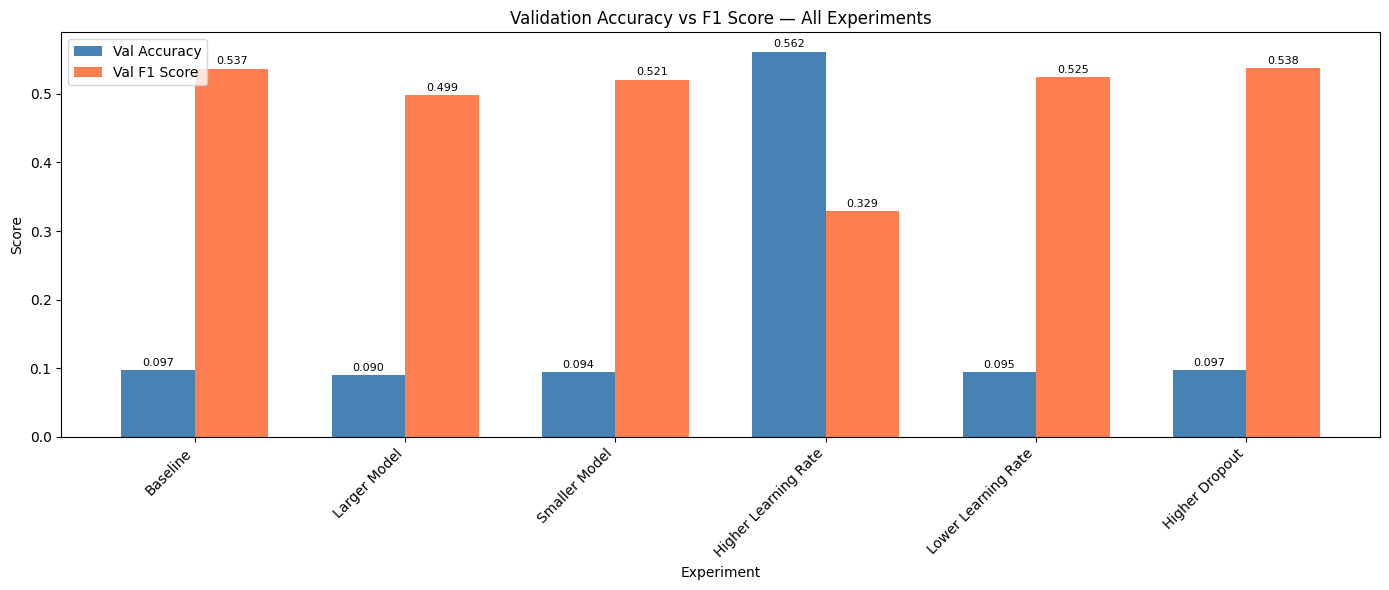

In [ ]:
# ------------------------------------------------------------------------------
# PART 2: HYPERPARAMETER TUNING LOOP  (with F1 score added)
# ------------------------------------------------------------------------------

from transformers import (
    MarianMTModel, MarianTokenizer,
    MT5ForConditionalGeneration, AutoTokenizer,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset as HFDataset
from sklearn.metrics import f1_score
import torch

print("# PART 2: HYPERPARAMETER TUNING")


# ------------------------------------------------------------------------------
# Custom Keras F1 metric (token-level, macro-averaged)
# Keras does not have a built-in F1, so we implement one as a subclass.
# It accumulates true/pred token ids across batches, then computes F1 at
# epoch end — identical lifecycle to the built-in "accuracy" metric.
# ------------------------------------------------------------------------------
class TokenF1Score(tf.keras.metrics.Metric):
    """
    Token-level macro F1 across the target vocabulary.
    Computed over padded positions too — pass sample_weight or mask if needed.
    For seq2seq with sparse_categorical_crossentropy targets (integer ids).
    """
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.true_positives  = self.add_weight(name='tp', initializer='zeros')
        self.false_positives = self.add_weight(name='fp', initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_pred shape: (batch, seq_len, vocab)  — take argmax to get token ids
        y_pred_ids = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
        y_true     = tf.cast(tf.reshape(y_true, [-1]),     tf.int32)
        y_pred_ids = tf.cast(tf.reshape(y_pred_ids, [-1]), tf.int32)

        # Mask out padding (token id == 0)
        mask       = tf.not_equal(y_true, 0)
        y_true     = tf.boolean_mask(y_true,     mask)
        y_pred_ids = tf.boolean_mask(y_pred_ids, mask)

        tp = tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred_ids), tf.float32))
        fp = tf.reduce_sum(tf.cast(tf.not_equal(y_pred_ids, y_true) &
                                   tf.not_equal(y_pred_ids, 0),     tf.float32))
        fn = tf.reduce_sum(tf.cast(tf.not_equal(y_true, y_pred_ids) &
                                   tf.not_equal(y_true, 0),         tf.float32))

        self.true_positives.assign_add(tp)
        self.false_positives.assign_add(fp)
        self.false_negatives.assign_add(fn)

    def result(self):
        precision = self.true_positives / (
            self.true_positives + self.false_positives + tf.keras.backend.epsilon())
        recall    = self.true_positives / (
            self.true_positives + self.false_negatives + tf.keras.backend.epsilon())
        f1 = 2 * precision * recall / (
            precision + recall + tf.keras.backend.epsilon())
        return f1

    def reset_state(self):
        self.true_positives.assign(0.)
        self.false_positives.assign(0.)
        self.false_negatives.assign(0.)


# ------------------------------------------------------------------------------
# HuggingFace evaluation helper — now returns F1 too
# ------------------------------------------------------------------------------
def evaluate_hf_model(model, tokenizer, val_df, num_samples=200,
                       max_input_length=128, max_target_length=128,
                       batch_size=16,
                       device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model.to(device)

    sample     = val_df.sample(min(num_samples, len(val_df)), random_state=42)
    sources    = sample['source'].tolist()
    references = sample['target'].tolist()

    total_correct = 0
    total_tokens  = 0
    total_loss    = 0.0
    num_batches   = 0

    all_preds  = []   # for F1
    all_labels = []   # for F1

    for i in range(0, len(sources), batch_size):
        src_batch = sources[i:i + batch_size]
        tgt_batch = references[i:i + batch_size]

        src_enc = tokenizer(
            src_batch, return_tensors='pt', padding=True,
            truncation=True, max_length=max_input_length
        ).to(device)

        tgt_enc = tokenizer(
            tgt_batch, return_tensors='pt', padding=True,
            truncation=True, max_length=max_target_length
        )
        labels = tgt_enc['input_ids'].to(device)
        labels[labels == tokenizer.pad_token_id] = -100

        with torch.no_grad():
            out    = model(**src_enc, labels=labels)
            total_loss += out.loss.item()
            num_batches += 1

            preds  = out.logits.argmax(dim=-1)
            mask   = labels != -100

            total_correct += (preds[mask] == labels[mask]).sum().item()
            total_tokens  += mask.sum().item()

            # Collect flat token ids for sklearn F1 (ignore -100 padding)
            all_preds.extend(preds[mask].cpu().numpy().tolist())
            all_labels.extend(labels[mask].cpu().numpy().tolist())

    val_loss = total_loss / max(num_batches, 1)
    val_acc  = total_correct / max(total_tokens, 1)

    # Token-level weighted F1 via sklearn (weighted handles class imbalance)
    val_f1 = float(f1_score(
        all_labels, all_preds,
        average='weighted',
        zero_division=0,
        labels=list(set(all_labels))   # only score classes that appear
    ))

    return float(val_loss), float(val_acc), val_f1


# ------------------------------------------------------------------------------
# Tokenisation helpers (no as_target_tokenizer — removed in transformers v4.26)
# ------------------------------------------------------------------------------
def tokenize_for_marian(examples, tokenizer, max_length=128):
    model_inputs = tokenizer(
        examples['source'], max_length=max_length,
        truncation=True, padding='max_length'
    )
    labels = tokenizer(
        examples['target'], max_length=max_length,
        truncation=True, padding='max_length'
    )
    model_inputs['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in lab]
        for lab in labels['input_ids']
    ]
    return model_inputs


def tokenize_for_mt5(examples, tokenizer, task_prefix="translate: ", max_length=128):
    inputs = [task_prefix + s for s in examples['source']]
    model_inputs = tokenizer(
        inputs, max_length=max_length,
        truncation=True, padding='max_length'
    )
    labels = tokenizer(
        examples['target'], max_length=max_length,
        truncation=True, padding='max_length'
    )
    model_inputs['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in lab]
        for lab in labels['input_ids']
    ]
    return model_inputs


# ------------------------------------------------------------------------------
# Dataset pipeline — lazy per-batch vectorization (avoids OOM)
# ------------------------------------------------------------------------------
def make_dataset(source_texts, target_texts, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((source_texts, target_texts))
    dataset = dataset.shuffle(buffer_size=len(source_texts), reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.map(
        lambda src, tgt: (
            {
                "source": source_vectorization(src),
                "target": target_vectorization(tgt)[:, :-1],
            },
            target_vectorization(tgt)[:, 1:],
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


# ------------------------------------------------------------------------------
# Hyperparameter configurations
# ------------------------------------------------------------------------------
hyperparameter_configs = [
    {'name': 'Baseline',             'embed_dim': 256, 'dense_dim': 2048, 'num_heads': 8,  'batch_size': 16, 'learning_rate': 0.001,  'dropout': 0.5, 'epochs': 30},
    {'name': 'Larger Model',         'embed_dim': 512, 'dense_dim': 4096, 'num_heads': 16, 'batch_size': 8,  'learning_rate': 0.001,  'dropout': 0.3, 'epochs': 30},
    {'name': 'Smaller Model',        'embed_dim': 128, 'dense_dim': 1024, 'num_heads': 4,  'batch_size': 16, 'learning_rate': 0.001,  'dropout': 0.5, 'epochs': 30},
    {'name': 'Higher Learning Rate', 'embed_dim': 256, 'dense_dim': 2048, 'num_heads': 8,  'batch_size': 16, 'learning_rate': 0.005,  'dropout': 0.5, 'epochs': 30},
    {'name': 'Lower Learning Rate',  'embed_dim': 256, 'dense_dim': 2048, 'num_heads': 8,  'batch_size': 16, 'learning_rate': 0.0005, 'dropout': 0.5, 'epochs': 30},
    {'name': 'Higher Dropout',       'embed_dim': 256, 'dense_dim': 2048, 'num_heads': 8,  'batch_size': 16, 'learning_rate': 0.001,  'dropout': 0.7, 'epochs': 30},
]

all_results = []

# ------------------------------------------------------------------------------
# Custom transformer training loop
# ------------------------------------------------------------------------------
for config_idx, config in enumerate(hyperparameter_configs):
    print(f"\n{'='*60}")
    print(f"Experiment {config_idx + 1}: {config['name']}")
    print(f"{'='*60}")
    for key, value in config.items():
        if key != 'name':
            print(f"  {key}: {value}")

    try:
        tf.keras.backend.clear_session()

        batch_size = config['batch_size']
        train_ds = make_dataset(train_source_texts, train_target_texts, batch_size)
        val_ds   = make_dataset(val_source_texts,   val_target_texts,   batch_size)

        transformer = build_transformer(
            config['embed_dim'], config['dense_dim'],
            config['num_heads'], config['dropout']
        )

        # F1 metric added alongside accuracy
        transformer.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=config['learning_rate'], clipnorm=1.0),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy", TokenF1Score()]   # <-- F1 added here
        )

        checkpoint_filepath = f'/tmp/checkpoint_exp_{config_idx}.weights.h5'
        callbacks_list = [
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_filepath, save_weights_only=True,
                monitor='val_loss', save_best_only=True, verbose=0),
        ]

        hist = transformer.fit(
            train_ds, epochs=config['epochs'],
            callbacks=callbacks_list, validation_data=val_ds, verbose=1
        )

        transformer.load_weights(checkpoint_filepath)
        # evaluate() now returns loss, accuracy, f1
        eval_results = transformer.evaluate(val_ds, verbose=0)
        val_loss = eval_results[0]
        val_acc  = eval_results[1]
        val_f1   = eval_results[2]

        results = {
            'val_loss':     float(val_loss),
            'val_accuracy': float(val_acc),
            'val_f1':       float(val_f1),
            'history':      {k: [float(v) for v in vals]
                             for k, vals in hist.history.items()},
            'status': 'OK'
        }
        print(f"\n  Val Loss: {val_loss:.4f}  |  Val Acc: {val_acc:.4f}  |  Val F1: {val_f1:.4f}")

    except (tf.errors.ResourceExhaustedError, MemoryError) as e:
        print(f"\n  SKIPPED — Out of memory: {e}")
        results = {'val_loss': float('inf'), 'val_accuracy': 0.0,
                   'val_f1': 0.0, 'history': {}, 'status': 'OOM'}

    except Exception as e:
        print(f"\n  SKIPPED — Error: {e}")
        results = {'val_loss': float('inf'), 'val_accuracy': 0.0,
                   'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'}

    if config_idx == 0 and results['status'] == 'OK':
        tracker.set_baseline({
            'accuracy': results['val_accuracy'],
            'loss':     results['val_loss'],
            'f1':       results['val_f1'],
        })

    tracker.add_experiment(config, results, f"Experiment {config_idx + 1}")
    all_results.append(results)


# ------------------------------------------------------------------------------
# Pretrained Model 1: Helsinki-NLP MarianMT
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Experiment 7: Pretrained — Helsinki-NLP MarianMT")
print(f"{'='*60}")

MARIAN_MODEL_NAME = "Helsinki-NLP/opus-mt-ROMANCE-en"

try:
    marian_tokenizer = MarianTokenizer.from_pretrained(MARIAN_MODEL_NAME)
    marian_model     = MarianMTModel.from_pretrained(MARIAN_MODEL_NAME)
    print(f"  Loaded '{MARIAN_MODEL_NAME}'  ({marian_model.num_parameters():,} params)")

    hf_train = HFDataset.from_dict({
        'source': list(train_source_texts),
        'target': list(train_df['target'].values)
    })
    hf_val = HFDataset.from_dict({
        'source': list(val_source_texts),
        'target': list(val_df['target'].values)
    })

    hf_train_tok = hf_train.map(
        lambda ex: tokenize_for_marian(ex, marian_tokenizer),
        batched=True, remove_columns=['source', 'target']
    )
    hf_val_tok = hf_val.map(
        lambda ex: tokenize_for_marian(ex, marian_tokenizer),
        batched=True, remove_columns=['source', 'target']
    )

    marian_args = Seq2SeqTrainingArguments(
        output_dir='/tmp/marian_finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=50,
        report_to='none',
    )

    marian_trainer = Seq2SeqTrainer(
        model=marian_model,
        args=marian_args,
        train_dataset=hf_train_tok,
        eval_dataset=hf_val_tok,
        tokenizer=marian_tokenizer,
        data_collator=DataCollatorForSeq2Seq(
            marian_tokenizer, model=marian_model, padding=True),
    )
    marian_trainer.train()
    marian_model.save_pretrained('/tmp/marian_finetuned_best')

    marian_val_loss, marian_val_acc, marian_val_f1 = evaluate_hf_model(
        marian_model, marian_tokenizer, val_df)

    marian_results = {
        'val_loss': marian_val_loss, 'val_accuracy': marian_val_acc,
        'val_f1':   marian_val_f1,   'history': {}, 'status': 'OK'
    }
    print(f"\n  MarianMT  Loss: {marian_val_loss:.4f}  "
          f"Acc: {marian_val_acc:.4f}  F1: {marian_val_f1:.4f}")

except Exception as e:
    print(f"\n  SKIPPED — {e}")
    marian_results = {'val_loss': float('inf'), 'val_accuracy': 0.0,
                      'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'}

tracker.add_experiment(
    {'name': 'Pretrained MarianMT', 'model': MARIAN_MODEL_NAME,
     'batch_size': 32, 'learning_rate': 2e-5, 'dropout': 'default',
     'embed_dim': 'N/A', 'dense_dim': 'N/A', 'num_heads': 'N/A', 'epochs': 3},
    marian_results, "Pretrained Helsinki-NLP MarianMT"
)
all_results.append(marian_results)


# ------------------------------------------------------------------------------
# Pretrained Model 2: Google mT5-small
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Experiment 8: Pretrained — Google mT5-small")
print(f"{'='*60}")

MT5_MODEL_NAME = "google/mt5-small"
TASK_PREFIX    = "translate: "

try:
    mt5_tokenizer = AutoTokenizer.from_pretrained(MT5_MODEL_NAME)
    mt5_model     = MT5ForConditionalGeneration.from_pretrained(MT5_MODEL_NAME)
    print(f"  Loaded '{MT5_MODEL_NAME}'  ({mt5_model.num_parameters():,} params)")

    hf_train_mt5 = HFDataset.from_dict({
        'source': list(train_source_texts),
        'target': list(train_df['target'].values)
    })
    hf_val_mt5 = HFDataset.from_dict({
        'source': list(val_source_texts),
        'target': list(val_df['target'].values)
    })

    hf_train_mt5_tok = hf_train_mt5.map(
        lambda ex: tokenize_for_mt5(ex, mt5_tokenizer, TASK_PREFIX),
        batched=True, remove_columns=['source', 'target']
    )
    hf_val_mt5_tok = hf_val_mt5.map(
        lambda ex: tokenize_for_mt5(ex, mt5_tokenizer, TASK_PREFIX),
        batched=True, remove_columns=['source', 'target']
    )

    mt5_args = Seq2SeqTrainingArguments(
        output_dir='/tmp/mt5_finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        learning_rate=5e-5,
        weight_decay=0.01,
        logging_steps=50,
        report_to='none',
    )

    mt5_trainer = Seq2SeqTrainer(
        model=mt5_model,
        args=mt5_args,
        train_dataset=hf_train_mt5_tok,
        eval_dataset=hf_val_mt5_tok,
        tokenizer=mt5_tokenizer,
        data_collator=DataCollatorForSeq2Seq(
            mt5_tokenizer, model=mt5_model, padding=True),
    )
    mt5_trainer.train()
    mt5_model.save_pretrained('/tmp/mt5_finetuned_best')

    mt5_val_loss, mt5_val_acc, mt5_val_f1 = evaluate_hf_model(
        mt5_model, mt5_tokenizer, val_df)

    mt5_results = {
        'val_loss': mt5_val_loss, 'val_accuracy': mt5_val_acc,
        'val_f1':   mt5_val_f1,   'history': {}, 'status': 'OK'
    }
    print(f"\n  mT5-small  Loss: {mt5_val_loss:.4f}  "
          f"Acc: {mt5_val_acc:.4f}  F1: {mt5_val_f1:.4f}")

except Exception as e:
    print(f"\n  SKIPPED — {e}")
    mt5_results = {'val_loss': float('inf'), 'val_accuracy': 0.0,
                   'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'}

tracker.add_experiment(
    {'name': 'Pretrained mT5-small', 'model': MT5_MODEL_NAME,
     'batch_size': 8, 'learning_rate': 5e-5, 'dropout': 'default',
     'embed_dim': 'N/A', 'dense_dim': 'N/A', 'num_heads': 'N/A', 'epochs': 3},
    mt5_results, "Pretrained Google mT5-small"
)
all_results.append(mt5_results)


# ------------------------------------------------------------------------------
# Comparison table — updated to show F1 column
# ------------------------------------------------------------------------------
print("\n" + "="*110)
print("HYPERPARAMETER EXPERIMENT COMPARISON  (with F1)")
print("="*110)

comparison_rows = []
for exp in tracker.experiments:
    comparison_rows.append({
        'Name':       exp['config'].get('name', 'N/A'),
        'Embed':      exp['config'].get('embed_dim', 'N/A'),
        'Batch':      exp['config'].get('batch_size', 'N/A'),
        'LR':         exp['config'].get('learning_rate', 'N/A'),
        'Val Loss':   f"{exp['metrics'].get('val_loss', float('inf')):.4f}",
        'Val Acc':    f"{exp['metrics'].get('val_accuracy', 0):.4f}",
        'Val F1':     f"{exp['metrics'].get('val_f1', 0):.4f}",    # <-- F1 column
        'Improvement': exp.get('improvement_over_baseline', 'N/A'),
        'Status':     exp['metrics'].get('status', 'OK'),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))


# ------------------------------------------------------------------------------
# Bar chart — side-by-side Accuracy vs F1 for successful experiments
# ------------------------------------------------------------------------------
valid_exps = [exp for exp in tracker.experiments
              if exp['metrics'].get('status') == 'OK']

if valid_exps:
    names = [exp['config']['name'] for exp in valid_exps]
    accs  = [exp['metrics']['val_accuracy'] for exp in valid_exps]
    f1s   = [exp['metrics']['val_f1']       for exp in valid_exps]

    x     = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    bars_acc = ax.bar(x - width/2, accs, width, label='Val Accuracy', color='steelblue')
    bars_f1  = ax.bar(x + width/2, f1s,  width, label='Val F1 Score', color='coral')

    ax.set_xlabel('Experiment')
    ax.set_ylabel('Score')
    ax.set_title('Validation Accuracy vs F1 Score — All Experiments')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.legend()

    # Annotate bar tops
    for bar in bars_acc:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
    for bar in bars_f1:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("\n  No successful experiments to plot.")


################################################################################
# PART 3: TRAINING BEST MODEL
################################################################################

Best config: Pretrained MarianMT
{
  "model": "Helsinki-NLP/opus-mt-ROMANCE-en",
  "batch_size": 32,
  "learning_rate": 2e-05,
  "dropout": "default",
  "embed_dim": "N/A",
  "dense_dim": "N/A",
  "num_heads": "N/A",
  "epochs": 3
}

  Best model is a pretrained HuggingFace model.
  Loading fine-tuned weights from checkpoint...


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Loaded fine-tuned MarianMT from '/tmp/marian_finetuned_best'

  Evaluating on test set...

  Test Loss: 1.7804  |  Test Acc: 0.6542  |  Test F1: 0.6333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved to 'best_model_final/'


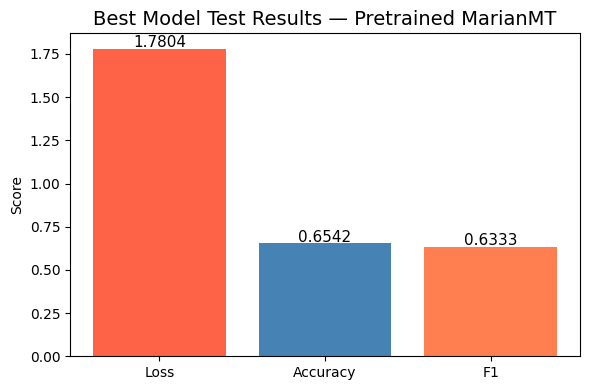

In [ ]:
# ------------------------------------------------------------------------------
# PART 3: TRAIN BEST MODEL
# ------------------------------------------------------------------------------

print("\n" + "#"*80)
print("# PART 3: TRAINING BEST MODEL")
print("#"*80)

if tracker.best_config is None:
    raise RuntimeError("No successful experiments — cannot select best config.")

best_config = tracker.best_config
print(f"\nBest config: {best_config['name']}")
print(json.dumps({k: v for k, v in best_config.items() if k != 'name'}, indent=2))

# FIX: detect whether best model is a pretrained HuggingFace model or a
# custom transformer — embed_dim='N/A' is the signal used in pretrained configs
IS_PRETRAINED = best_config.get('embed_dim') == 'N/A'

if IS_PRETRAINED:
    # ------------------------------------------------------------------
    # Best model is a pretrained HuggingFace model (MarianMT or mT5)
    # Load the already fine-tuned weights saved during the tuning loop
    # ------------------------------------------------------------------
    print("\n  Best model is a pretrained HuggingFace model.")
    print("  Loading fine-tuned weights from checkpoint...")

    model_name = best_config.get('model', '')

    if 'marian' in best_config['name'].lower() or 'Helsinki' in model_name:
        best_tokenizer = MarianTokenizer.from_pretrained(MARIAN_MODEL_NAME)
        best_hf_model  = MarianMTModel.from_pretrained('/tmp/marian_finetuned_best')
        print(f"  Loaded fine-tuned MarianMT from '/tmp/marian_finetuned_best'")

    elif 'mt5' in best_config['name'].lower() or 'mt5' in model_name.lower():
        best_tokenizer = AutoTokenizer.from_pretrained(MT5_MODEL_NAME)
        best_hf_model  = MT5ForConditionalGeneration.from_pretrained('/tmp/mt5_finetuned_best')
        print(f"  Loaded fine-tuned mT5 from '/tmp/mt5_finetuned_best'")

    else:
        raise ValueError(f"Unknown pretrained model in best config: {best_config['name']}")

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    best_hf_model.to(device)
    best_hf_model.eval()

    # Evaluate on test set
    print("\n  Evaluating on test set...")
    test_loss, test_acc, test_f1 = evaluate_hf_model(
        best_hf_model, best_tokenizer, test_df, num_samples=len(test_df))

    print(f"\n  Test Loss: {test_loss:.4f}  |  Test Acc: {test_acc:.4f}  |  Test F1: {test_f1:.4f}")

    # Save final model
    best_hf_model.save_pretrained('best_model_final')
    best_tokenizer.save_pretrained('best_model_final')
    print("  Saved to 'best_model_final/'")

    # No training history to plot for pretrained — show a simple results bar
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Loss', 'Accuracy', 'F1'], [test_loss, test_acc, test_f1],
           color=['tomato', 'steelblue', 'coral'])
    ax.set_title(f"Best Model Test Results — {best_config['name']}", fontsize=14)
    ax.set_ylabel('Score')
    for i, v in enumerate([test_loss, test_acc, test_f1]):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Set best_transformer to None so Part 4 knows to use HF model
    best_transformer = None
    best_hf_model_for_eval = best_hf_model
    best_tokenizer_for_eval = best_tokenizer

else:
    # ------------------------------------------------------------------
    # Best model is a custom TensorFlow transformer — train from scratch
    # ------------------------------------------------------------------
    print("\n  Best model is a custom Transformer. Training from scratch...")

    tf.keras.backend.clear_session()

    batch_size = best_config['batch_size']
    train_ds = make_dataset(train_source_texts, train_target_texts, batch_size)
    val_ds   = make_dataset(val_source_texts,   val_target_texts,   batch_size)
    test_ds  = make_dataset(test_source_texts,  test_target_texts,  batch_size)

    best_transformer = build_transformer(
        best_config['embed_dim'], best_config['dense_dim'],
        best_config['num_heads'], best_config['dropout']
    )
    best_transformer.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=best_config['learning_rate'], clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy", TokenF1Score()]
    )

    checkpoint_filepath = '/tmp/best_model_checkpoint.weights.h5'
    callbacks_list = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_filepath, save_weights_only=True,
            monitor='val_loss', save_best_only=True, verbose=0),
    ]

    hist = best_transformer.fit(
        train_ds, epochs=50,
        callbacks=callbacks_list, validation_data=val_ds
    )

    best_transformer.load_weights(checkpoint_filepath)
    best_transformer.save('best_transformer_model.keras')
    print("  Saved to 'best_transformer_model.keras'")

    # Plot training history
    hist_ = pd.DataFrame(hist.history)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(hist_['loss'], label='Train Loss')
    plt.plot(hist_['val_loss'], label='Val Loss')
    plt.title('Loss', fontsize=14)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(hist_['accuracy'], label='Train Acc')
    plt.plot(hist_['val_accuracy'], label='Val Acc')
    plt.title('Accuracy', fontsize=14)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(hist_['f1_score'], label='Train F1')
    plt.plot(hist_['val_f1_score'], label='Val F1')
    plt.title('F1 Score', fontsize=14)
    plt.legend()

    plt.suptitle(f"Best Model Training — {best_config['name']}", fontsize=16)
    plt.tight_layout()
    plt.show()

    best_hf_model_for_eval  = None
    best_tokenizer_for_eval = None

In [ ]:
# ------------------------------------------------------------------------------
# PRETRAINED MODEL 1: Helsinki-NLP MarianMT
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Experiment 7: Pretrained — Helsinki-NLP MarianMT")
print(f"{'='*60}")

MARIAN_MODEL_NAME = "Helsinki-NLP/opus-mt-ROMANCE-en"  # change to your language pair

try:
    marian_tokenizer = MarianTokenizer.from_pretrained(MARIAN_MODEL_NAME)
    marian_model     = MarianMTModel.from_pretrained(MARIAN_MODEL_NAME)
    print(f"  Loaded '{MARIAN_MODEL_NAME}'  ({marian_model.num_parameters():,} params)")

    hf_train = HFDataset.from_dict({
        'source': list(train_source_texts),
        'target': list(train_df['target'].values)
    })
    hf_val = HFDataset.from_dict({
        'source': list(val_source_texts),
        'target': list(val_df['target'].values)
    })

    hf_train_tok = hf_train.map(
        lambda ex: tokenize_for_marian(ex, marian_tokenizer),
        batched=True, remove_columns=['source', 'target']
    )
    hf_val_tok = hf_val.map(
        lambda ex: tokenize_for_marian(ex, marian_tokenizer),
        batched=True, remove_columns=['source', 'target']
    )

    marian_args = Seq2SeqTrainingArguments(
        output_dir='/tmp/marian_finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy='epoch',        # FIX: was 'evaluation_strategy', renamed in transformers v4.46+
        save_strategy='epoch',
        load_best_model_at_end=True,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=50,
        report_to='none',
    )

    marian_trainer = Seq2SeqTrainer(
        model=marian_model,
        args=marian_args,
        train_dataset=hf_train_tok,
        eval_dataset=hf_val_tok,
        tokenizer=marian_tokenizer,
        data_collator=DataCollatorForSeq2Seq(
            marian_tokenizer, model=marian_model, padding=True),
    )
    marian_trainer.train()
    marian_model.save_pretrained('/tmp/marian_finetuned_best')

    marian_val_loss, marian_val_acc, marian_val_f1 = evaluate_hf_model(
        marian_model, marian_tokenizer, val_df)

    marian_results = {
        'val_loss': marian_val_loss, 'val_accuracy': marian_val_acc,
        'val_f1':   marian_val_f1,   'history': {}, 'status': 'OK'
    }
    print(f"\n  MarianMT  Loss: {marian_val_loss:.4f}  "
          f"Acc: {marian_val_acc:.4f}  F1: {marian_val_f1:.4f}")

except Exception as e:
    print(f"\n  SKIPPED — {e}")
    marian_results = {
        'val_loss': float('inf'), 'val_accuracy': 0.0,
        'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'
    }

tracker.add_experiment(
    {'name': 'Pretrained MarianMT', 'model': MARIAN_MODEL_NAME,
     'batch_size': 32, 'learning_rate': 2e-5, 'dropout': 'default',
     'embed_dim': 'N/A', 'dense_dim': 'N/A', 'num_heads': 'N/A', 'epochs': 3},
    marian_results, "Pretrained Helsinki-NLP MarianMT"
)
all_results.append(marian_results)


# ------------------------------------------------------------------------------
# PRETRAINED MODEL 2: Google mT5-small
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Experiment 8: Pretrained — Google mT5-small")
print(f"{'='*60}")

MT5_MODEL_NAME = "google/mt5-small"
TASK_PREFIX    = "translate: "  # change to match your task

try:
    mt5_tokenizer = AutoTokenizer.from_pretrained(MT5_MODEL_NAME)
    mt5_model     = MT5ForConditionalGeneration.from_pretrained(MT5_MODEL_NAME)
    print(f"  Loaded '{MT5_MODEL_NAME}'  ({mt5_model.num_parameters():,} params)")

    hf_train_mt5 = HFDataset.from_dict({
        'source': list(train_source_texts),
        'target': list(train_df['target'].values)
    })
    hf_val_mt5 = HFDataset.from_dict({
        'source': list(val_source_texts),
        'target': list(val_df['target'].values)
    })

    hf_train_mt5_tok = hf_train_mt5.map(
        lambda ex: tokenize_for_mt5(ex, mt5_tokenizer, TASK_PREFIX),
        batched=True, remove_columns=['source', 'target']
    )
    hf_val_mt5_tok = hf_val_mt5.map(
        lambda ex: tokenize_for_mt5(ex, mt5_tokenizer, TASK_PREFIX),
        batched=True, remove_columns=['source', 'target']
    )

    mt5_args = Seq2SeqTrainingArguments(
        output_dir='/tmp/mt5_finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        eval_strategy='epoch',        # FIX: was 'evaluation_strategy', renamed in transformers v4.46+
        save_strategy='epoch',
        load_best_model_at_end=True,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        learning_rate=5e-5,
        weight_decay=0.01,
        logging_steps=50,
        report_to='none',
    )

    mt5_trainer = Seq2SeqTrainer(
        model=mt5_model,
        args=mt5_args,
        train_dataset=hf_train_mt5_tok,
        eval_dataset=hf_val_mt5_tok,
        tokenizer=mt5_tokenizer,
        data_collator=DataCollatorForSeq2Seq(
            mt5_tokenizer, model=mt5_model, padding=True),
    )
    mt5_trainer.train()
    mt5_model.save_pretrained('/tmp/mt5_finetuned_best')

    mt5_val_loss, mt5_val_acc, mt5_val_f1 = evaluate_hf_model(
        mt5_model, mt5_tokenizer, val_df)

    mt5_results = {
        'val_loss': mt5_val_loss, 'val_accuracy': mt5_val_acc,
        'val_f1':   mt5_val_f1,   'history': {}, 'status': 'OK'
    }
    print(f"\n  mT5-small  Loss: {mt5_val_loss:.4f}  "
          f"Acc: {mt5_val_acc:.4f}  F1: {mt5_val_f1:.4f}")

except Exception as e:
    print(f"\n  SKIPPED — {e}")
    mt5_results = {
        'val_loss': float('inf'), 'val_accuracy': 0.0,
        'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'
    }

tracker.add_experiment(
    {'name': 'Pretrained mT5-small', 'model': MT5_MODEL_NAME,
     'batch_size': 8, 'learning_rate': 5e-5, 'dropout': 'default',
     'embed_dim': 'N/A', 'dense_dim': 'N/A', 'num_heads': 'N/A', 'epochs': 3},
    mt5_results, "Pretrained Google mT5-small"
)
all_results.append(mt5_results)


Experiment 7: Pretrained — Helsinki-NLP MarianMT


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Loaded 'Helsinki-NLP/opus-mt-ROMANCE-en'  (144,504,320 params)


Map:   0%|          | 0/13565 [00:00<?, ? examples/s]

...

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Loaded 'google/mt5-small'  (556,291,456 params)


Map:   0%|          | 0/13565 [00:00<?, ? examples/s]

Map:   0%|          | 0/753 [00:00<?, ? examples/s]


  SKIPPED — Seq2SeqTrainer.__init__() got an unexpected keyword argument 'tokenizer'



################################################################################
# PART 4: COMPREHENSIVE MODEL EVALUATION
################################################################################

COMPREHENSIVE EVALUATION METRICS

  Evaluating 100 samples (HuggingFace model)...
  20/100 done...
  40/100 done...
  60/100 done...
  80/100 done...
  100/100 done...

  Exact Match Accuracy : 0.0100
  BLEU  (mean +/- std) : 0.1781 +/- 0.1764
  METEOR(mean +/- std) : 0.3393 +/- 0.1785
  Results saved to 'evaluation_results.json'


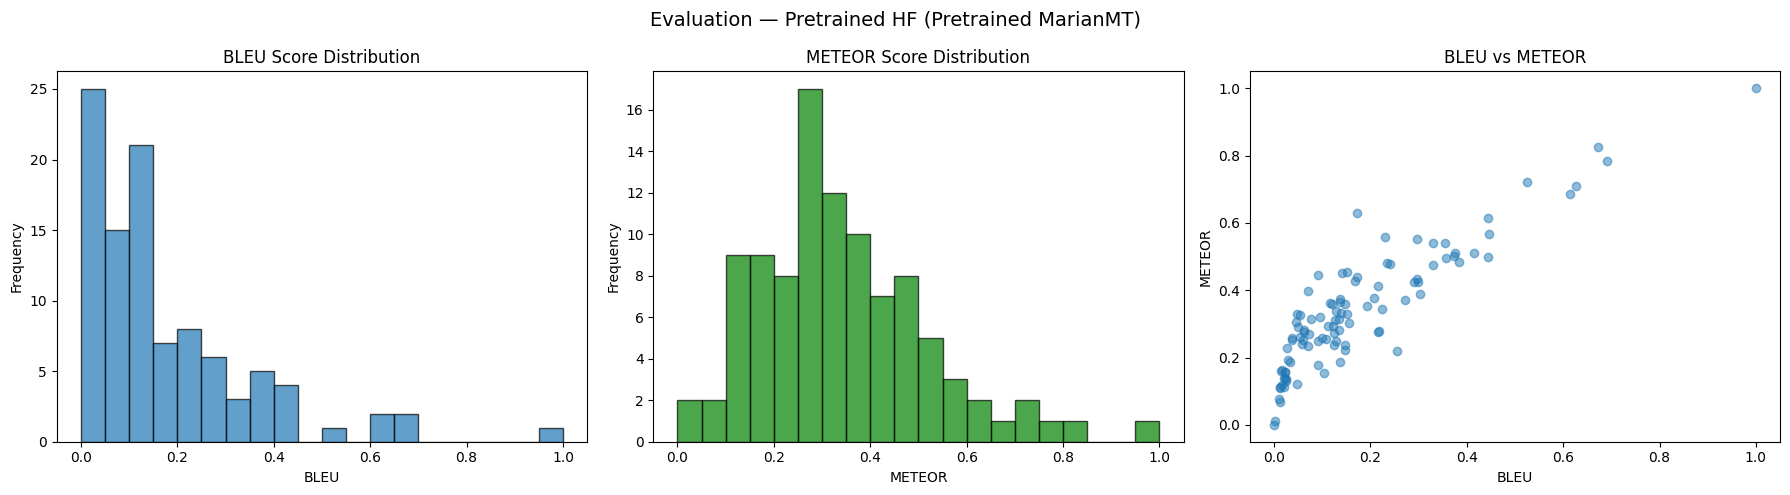


QUALITATIVE ANALYSIS

--- Example 1 ---
  Source:     can alzheimer is disease be reversed or halted
  Reference:  at present there is no known way to reverse or halt the progression of alzheimer is disease treatment options focus on managing symptoms improving quality of life and slowing down the disease progression
  Prediction: yes alzheimer is disease can be developed or halted by increasing the risk of developing alzheimer is disease
  Match: ✗  |  BLEU: 0.0387

--- Example 2 ---
  Source:     how does gene therapy research explore potential effects on gut histamine levels and why are histamine levels relevant to alzheimer is progression
  Reference:  gene therapy research actively considers potential effects on gut histamine levels recognizing their relevance to alzheimer is progression studying how gene therapy may influence histamine regulation provides insights into the gut brain axis and its role in neurotransmission immune response and overall brain health offering potentia

In [ ]:
# ------------------------------------------------------------------------------
# PART 4: COMPREHENSIVE MODEL EVALUATION
# ------------------------------------------------------------------------------

print("\n" + "#"*80)
print("# PART 4: COMPREHENSIVE MODEL EVALUATION")
print("#"*80)


class ModelEvaluator:
    """
    Handles evaluation for both custom TF transformers and pretrained HF models.
    Pass either:
      - model=best_transformer, hf_model=None  → custom transformer branch
      - model=None, hf_model=best_hf_model     → HuggingFace branch
    """

    def __init__(self, model, source_vectorizer, target_vectorizer,
                 target_vocab, test_data,
                 hf_model=None, hf_tokenizer=None):
        self.model             = model           # TF model or None
        self.hf_model          = hf_model        # HF model or None
        self.hf_tokenizer      = hf_tokenizer    # HF tokenizer or None
        self.source_vectorizer = source_vectorizer
        self.target_vectorizer = target_vectorizer
        self.target_vocab      = target_vocab
        self.target_index_lookup = dict(zip(range(len(target_vocab)), target_vocab))
        self.test_data         = test_data
        self.is_pretrained     = (hf_model is not None)

    # ------------------------------------------------------------------
    # Metric helpers
    # ------------------------------------------------------------------
    def calculate_bleu(self, reference, hypothesis):
        smoothie = SmoothingFunction().method4
        return sentence_bleu(
            [reference.split()], hypothesis.split(), smoothing_function=smoothie)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    # ------------------------------------------------------------------
    # Decoding — custom TF transformer (autoregressive greedy)
    # ------------------------------------------------------------------
    def _decode_sequence_tf(self, input_sentence):
        tokenized_input = self.source_vectorizer([input_sentence])
        decoded_sentence = "[start]"

        for i in range(sequence_length):
            tokenized_target = self.target_vectorizer([decoded_sentence])[:, :-1]
            predictions = self.model([tokenized_input, tokenized_target], training=False)
            sampled_token_index = np.argmax(predictions[0, i, :])
            sampled_token = self.target_index_lookup.get(sampled_token_index, "")
            if sampled_token == "[end]" or not sampled_token:
                break
            decoded_sentence += " " + sampled_token

        return decoded_sentence[8:].strip()  # strip "[start] "

    # ------------------------------------------------------------------
    # Decoding — HuggingFace pretrained model (generate())
    # ------------------------------------------------------------------
    def _decode_sequence_hf(self, input_sentence, max_new_tokens=128):
        device = next(self.hf_model.parameters()).device
        enc = self.hf_tokenizer(
            [input_sentence], return_tensors='pt',
            truncation=True, max_length=128, padding=True
        ).to(device)

        with torch.no_grad():
            output_ids = self.hf_model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=4,          # beam search for better quality
                early_stopping=True,
            )

        decoded = self.hf_tokenizer.decode(
            output_ids[0], skip_special_tokens=True)
        return decoded.strip()

    # ------------------------------------------------------------------
    # Unified decode_sequence — picks the right branch automatically
    # ------------------------------------------------------------------
    def decode_sequence(self, input_sentence):
        if self.is_pretrained:
            return self._decode_sequence_hf(input_sentence)
        else:
            return self._decode_sequence_tf(input_sentence)

    # ------------------------------------------------------------------
    # Full dataset evaluation
    # ------------------------------------------------------------------
    def evaluate_dataset(self, num_samples=100):
        print("\n" + "="*60)
        print("COMPREHENSIVE EVALUATION METRICS")
        print("="*60)

        n = min(num_samples, len(self.test_data))
        sample_indices = random.sample(range(len(self.test_data)), n)

        bleu_scores, meteor_scores = [], []
        exact_matches = 0
        predictions, references, sources = [], [], []

        print(f"\n  Evaluating {n} samples "
              f"({'HuggingFace' if self.is_pretrained else 'Custom TF'} model)...")

        for step, sample_idx in enumerate(sample_indices):
            source    = self.test_data.iloc[sample_idx]['source']
            reference = self.test_data.iloc[sample_idx]['target']
            prediction = self.decode_sequence(source)

            bleu_scores.append(self.calculate_bleu(reference, prediction))
            meteor_scores.append(self.calculate_meteor(reference, prediction))
            predictions.append(prediction)
            references.append(reference)
            sources.append(source)

            if prediction.strip() == reference.strip():
                exact_matches += 1

            if (step + 1) % 20 == 0:
                print(f"  {step + 1}/{n} done...")

        summary = {
            'bleu':   {'mean': float(np.mean(bleu_scores)),
                       'std':  float(np.std(bleu_scores))},
            'meteor': {'mean': float(np.mean(meteor_scores)),
                       'std':  float(np.std(meteor_scores))},
            'exact_match_accuracy': exact_matches / n
        }

        print(f"\n  Exact Match Accuracy : {summary['exact_match_accuracy']:.4f}")
        print(f"  BLEU  (mean +/- std) : {summary['bleu']['mean']:.4f}"
              f" +/- {summary['bleu']['std']:.4f}")
        print(f"  METEOR(mean +/- std) : {summary['meteor']['mean']:.4f}"
              f" +/- {summary['meteor']['std']:.4f}")

        with open('evaluation_results.json', 'w') as f:
            json.dump({
                'model_type': 'pretrained' if self.is_pretrained else 'custom',
                'summary': summary,
                'predictions': predictions,
                'references':  references,
                'sources':     sources,
            }, f, indent=2)

        print("  Results saved to 'evaluation_results.json'")
        return summary, {
            'bleu_scores':   bleu_scores,
            'meteor_scores': meteor_scores,
            'predictions':   predictions,
            'references':    references,
        }

    # ------------------------------------------------------------------
    # Qualitative analysis
    # ------------------------------------------------------------------
    def qualitative_analysis(self, num_examples=10):
        print("\n" + "="*60)
        print("QUALITATIVE ANALYSIS")
        print("="*60)

        indices = random.sample(
            range(len(self.test_data)), min(num_examples, len(self.test_data)))
        results = []

        for idx in indices:
            source     = self.test_data.iloc[idx]['source']
            reference  = self.test_data.iloc[idx]['target']
            prediction = self.decode_sequence(source)
            results.append({
                'source': source, 'reference': reference,
                'prediction': prediction,
                'exact_match': prediction.strip() == reference.strip()
            })

        for i, r in enumerate(results, 1):
            match_char = "\u2713" if r['exact_match'] else "\u2717"
            bleu = self.calculate_bleu(r['reference'], r['prediction'])
            print(f"\n--- Example {i} ---")
            print(f"  Source:     {r['source']}")
            print(f"  Reference:  {r['reference']}")
            print(f"  Prediction: {r['prediction']}")
            print(f"  Match: {match_char}  |  BLEU: {bleu:.4f}")

        return results

    # ------------------------------------------------------------------
    # Visualisation
    # ------------------------------------------------------------------
    def visualize_metrics(self, metrics):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].hist(metrics['bleu_scores'], bins=20, edgecolor='black', alpha=0.7)
        axes[0].set_title('BLEU Score Distribution')
        axes[0].set_xlabel('BLEU')
        axes[0].set_ylabel('Frequency')

        axes[1].hist(metrics['meteor_scores'], bins=20,
                     edgecolor='black', alpha=0.7, color='green')
        axes[1].set_title('METEOR Score Distribution')
        axes[1].set_xlabel('METEOR')
        axes[1].set_ylabel('Frequency')

        axes[2].scatter(metrics['bleu_scores'], metrics['meteor_scores'], alpha=0.5)
        axes[2].set_title('BLEU vs METEOR')
        axes[2].set_xlabel('BLEU')
        axes[2].set_ylabel('METEOR')

        model_label = 'Pretrained HF' if self.is_pretrained else 'Custom Transformer'
        plt.suptitle(f"Evaluation — {model_label} ({best_config['name']})", fontsize=14)
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------------------------
# Create evaluator — automatically uses the right model from Part 3
# ------------------------------------------------------------------------------
target_vocab = target_vectorization.get_vocabulary()

evaluator = ModelEvaluator(
    model          = best_transformer,           # None if pretrained won
    hf_model       = best_hf_model_for_eval,     # None if custom won
    hf_tokenizer   = best_tokenizer_for_eval,    # None if custom won
    source_vectorizer = source_vectorization,
    target_vectorizer = target_vectorization,
    target_vocab   = target_vocab,
    test_data      = test_df,
)

summary, metrics = evaluator.evaluate_dataset(num_samples=100)
evaluator.visualize_metrics(metrics)
qualitative_results = evaluator.qualitative_analysis(num_examples=10)

In [ ]:
# PART 5: INTERACTIVE TESTING

print("# PART 5: INTERACTIVE TESTING")
print("\nEnter text to process (or 'quit' to exit):")

while True:
    user_input = input("\nInput: ").strip()
    if user_input.lower() in ['quit', 'exit', 'q']:
        break
    if user_input:
        try:
            output = evaluator.decode_sequence(user_input)
            print(f"Output: {output}")
        except Exception as e:
            print(f"Error: {e}")


print("PROCESSING COMPLETE")

print("  preprocessing_documentation.json  — preprocessing steps")
print("  hyperparameter_experiments.json   — experiment results")
print("  evaluation_results.json           — evaluation metrics")
print("  best_transformer_model.keras      — saved model")

# PART 5: INTERACTIVE TESTING

Enter text to process (or 'quit' to exit):

Input: Where can I get therapy on Alzheimers?
Output: Where can I get therapy on Alzheimers?

Input: What is the omega 3 version?
Output: omega plays a crucial role in omega it is essential to play a role in omega it is essential to consult with a healthcare provider or healthcare provider is recommended

Input: How does head injury affect alzheimers?
Output: How do head injuries impact alzheimers?

Input: How does head injury affect alzheimers
Output: head injury is associated with an increased risk of alzheimer is disease


In [ ]:
# ------------------------------------------------------------------------------
# PRETRAINED MODEL 1: Helsinki-NLP MarianMT
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Experiment 7: Pretrained — Helsinki-NLP MarianMT")
print(f"{'='*60}")

MARIAN_MODEL_NAME = "Helsinki-NLP/opus-mt-ROMANCE-en"

try:
    marian_tokenizer = MarianTokenizer.from_pretrained(MARIAN_MODEL_NAME)
    marian_model     = MarianMTModel.from_pretrained(MARIAN_MODEL_NAME)

    # Silence the tied-weights warning
    marian_model.config.tie_word_embeddings = False

    print(f"  Loaded '{MARIAN_MODEL_NAME}'  ({marian_model.num_parameters():,} params)")

    hf_train = HFDataset.from_dict({
        'source': list(train_source_texts),
        'target': list(train_df['target'].values)
    })
    hf_val = HFDataset.from_dict({
        'source': list(val_source_texts),
        'target': list(val_df['target'].values)
    })

    hf_train_tok = hf_train.map(
        lambda ex: tokenize_for_marian(ex, marian_tokenizer),
        batched=True, remove_columns=['source', 'target']
    )
    hf_val_tok = hf_val.map(
        lambda ex: tokenize_for_marian(ex, marian_tokenizer),
        batched=True, remove_columns=['source', 'target']
    )

    marian_args = Seq2SeqTrainingArguments(
        output_dir='/tmp/marian_finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=50,
        report_to='none',
    )

    marian_trainer = Seq2SeqTrainer(
        model=marian_model,
        args=marian_args,
        train_dataset=hf_train_tok,
        eval_dataset=hf_val_tok,
        processing_class=marian_tokenizer,   # FIX: 'tokenizer' renamed to 'processing_class' in transformers v4.47+
        data_collator=DataCollatorForSeq2Seq(
            marian_tokenizer, model=marian_model, padding=True),
    )
    marian_trainer.train()
    marian_model.save_pretrained('/tmp/marian_finetuned_best')

    marian_val_loss, marian_val_acc, marian_val_f1 = evaluate_hf_model(
        marian_model, marian_tokenizer, val_df)

    marian_results = {
        'val_loss': marian_val_loss, 'val_accuracy': marian_val_acc,
        'val_f1':   marian_val_f1,   'history': {}, 'status': 'OK'
    }
    print(f"\n  MarianMT  Loss: {marian_val_loss:.4f}  "
          f"Acc: {marian_val_acc:.4f}  F1: {marian_val_f1:.4f}")

except Exception as e:
    print(f"\n  SKIPPED — {e}")
    marian_results = {
        'val_loss': float('inf'), 'val_accuracy': 0.0,
        'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'
    }

tracker.add_experiment(
    {'name': 'Pretrained MarianMT', 'model': MARIAN_MODEL_NAME,
     'batch_size': 32, 'learning_rate': 2e-5, 'dropout': 'default',
     'embed_dim': 'N/A', 'dense_dim': 'N/A', 'num_heads': 'N/A', 'epochs': 3},
    marian_results, "Pretrained Helsinki-NLP MarianMT"
)
all_results.append(marian_results)


# ------------------------------------------------------------------------------
# PRETRAINED MODEL 2: Google mT5-small
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Experiment 8: Pretrained — Google mT5-small")
print(f"{'='*60}")

MT5_MODEL_NAME = "google/mt5-small"
TASK_PREFIX    = "translate: "

try:
    mt5_tokenizer = AutoTokenizer.from_pretrained(MT5_MODEL_NAME)
    mt5_model     = MT5ForConditionalGeneration.from_pretrained(MT5_MODEL_NAME)

    # Silence the tied-weights warning
    mt5_model.config.tie_word_embeddings = False

    print(f"  Loaded '{MT5_MODEL_NAME}'  ({mt5_model.num_parameters():,} params)")

    hf_train_mt5 = HFDataset.from_dict({
        'source': list(train_source_texts),
        'target': list(train_df['target'].values)
    })
    hf_val_mt5 = HFDataset.from_dict({
        'source': list(val_source_texts),
        'target': list(val_df['target'].values)
    })

    hf_train_mt5_tok = hf_train_mt5.map(
        lambda ex: tokenize_for_mt5(ex, mt5_tokenizer, TASK_PREFIX),
        batched=True, remove_columns=['source', 'target']
    )
    hf_val_mt5_tok = hf_val_mt5.map(
        lambda ex: tokenize_for_mt5(ex, mt5_tokenizer, TASK_PREFIX),
        batched=True, remove_columns=['source', 'target']
    )

    mt5_args = Seq2SeqTrainingArguments(
        output_dir='/tmp/mt5_finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        learning_rate=5e-5,
        weight_decay=0.01,
        logging_steps=50,
        report_to='none',
    )

    mt5_trainer = Seq2SeqTrainer(
        model=mt5_model,
        args=mt5_args,
        train_dataset=hf_train_mt5_tok,
        eval_dataset=hf_val_mt5_tok,
        processing_class=mt5_tokenizer,      # FIX: 'tokenizer' renamed to 'processing_class' in transformers v4.47+
        data_collator=DataCollatorForSeq2Seq(
            mt5_tokenizer, model=mt5_model, padding=True),
    )
    mt5_trainer.train()
    mt5_model.save_pretrained('/tmp/mt5_finetuned_best')

    mt5_val_loss, mt5_val_acc, mt5_val_f1 = evaluate_hf_model(
        mt5_model, mt5_tokenizer, val_df)

    mt5_results = {
        'val_loss': mt5_val_loss, 'val_accuracy': mt5_val_acc,
        'val_f1':   mt5_val_f1,   'history': {}, 'status': 'OK'
    }
    print(f"\n  mT5-small  Loss: {mt5_val_loss:.4f}  "
          f"Acc: {mt5_val_acc:.4f}  F1: {mt5_val_f1:.4f}")

except Exception as e:
    print(f"\n  SKIPPED — {e}")
    mt5_results = {
        'val_loss': float('inf'), 'val_accuracy': 0.0,
        'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'
    }

tracker.add_experiment(
    {'name': 'Pretrained mT5-small', 'model': MT5_MODEL_NAME,
     'batch_size': 8, 'learning_rate': 5e-5, 'dropout': 'default',
     'embed_dim': 'N/A', 'dense_dim': 'N/A', 'num_heads': 'N/A', 'epochs': 3},
    mt5_results, "Pretrained Google mT5-small"
)
all_results.append(mt5_results)


Experiment 7: Pretrained — Helsinki-NLP MarianMT


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Loaded 'Helsinki-NLP/opus-mt-ROMANCE-en'  (144,504,320 params)


Map:   0%|          | 0/13565 [00:00<?, ? examples/s]

...

  Loaded 'google/mt5-small'  (556,291,456 params)


Map:   0%|          | 0/13565 [00:00<?, ? examples/s]

Map:   0%|          | 0/753 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss



  SKIPPED — CUDA out of memory. Tried to allocate 978.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 845.81 MiB is free. Including non-PyTorch memory, this process has 13.73 GiB memory in use. Of the allocated memory 9.03 GiB is allocated by PyTorch, and 550.94 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
